In [1]:
!python -V

Python 3.12.7


In [18]:
import pandas as pd
import numpy as np

In [3]:
import pickle

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error

In [6]:
import mlflow


mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='/home/oduorri/mlops-zoomcamp/mlops-zoomcamp/02-experiment-tracking/mlruns/1', creation_time=1750054878651, experiment_id='1', last_update_time=1750054878651, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [7]:
df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet')

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [8]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

mean_squared_error(y_train, y_pred)
mean_squared_error(y_train, y_pred, squared=False)

TypeError: got an unexpected keyword argument 'squared'

/tmp/ipykernel_11494/1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')


/tmp/ipykernel_11494/1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


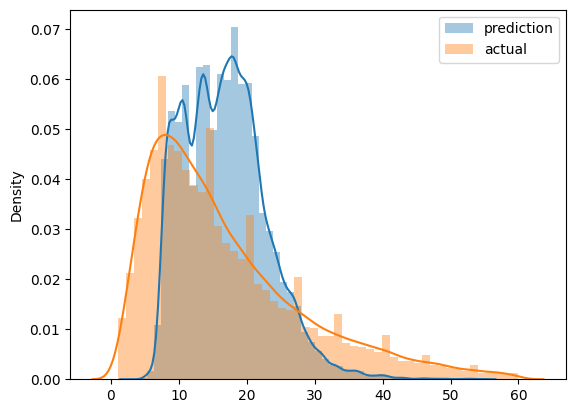

In [9]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [10]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [11]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2021-02.parquet')

In [12]:
len(df_train), len(df_val)

(73908, 61921)

In [13]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [14]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [15]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(rmse)

7.758715212021978


In [20]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [22]:
with mlflow.start_run():

    mlflow.set_tag("developer", "cristian")

    mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.csv")
    mlflow.log_param("valid-data-path", "./data/green_tripdata_2021-02.csv")

    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")

In [23]:
import xgboost as xgb

In [24]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [25]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [28]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [29]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

 ... (more hidden) ...

/home/oduorri/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [07:15:30] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:7.99559
[1]	validation-rmse:6.97557
[2]	validation-rmse:6.71146
[3]	validation-rmse:6.61984
[4]	validation-rmse:6.59198
[5]	validation-rmse:6.57613
[6]	validation-rmse:6.55924
[7]	validation-rmse:6.55084
[8]	validation-rmse:6.54623
[9]	validation-rmse:6.53924
[10]	validation-rmse:6.53517
[11]	validation-rmse:6.53229
[12]	validation-rmse:6.52769
[13]	validation-rmse:6.52686
[14]	validation-rmse:6.52279
[15]	validation-rmse:6.51901
[16]	validation-rmse:6.51575
[17]	validation-rmse:6.51306
[18]	validation-rmse:6.50874
[19]	validation-rmse:6.50592
[20]	validation-rmse:6.50505
[21]	validation-rmse:6.50317
[22]	validation-rmse:6.50397
[23]	validation-rmse:6.50272
[24]	validation-rmse:6.50344
[25]	validation-rmse:6.50219
[26]	validation-rmse:6.49982
[27]	validation-rmse:6.49702
[28]	validation-rmse:6.49633
[29]	validation-rmse:6.49643
[30]	validation-rmse:6.49415
[31]	validation-rmse:6.49353
[32]	validation-rmse:6.49197
[33]	validation-rmse:6.49047
[34]	validation-rmse:6.4

/home/oduorri/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [07:15:57] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:10.99989
[1]	validation-rmse:10.03119
[2]	validation-rmse:9.26454
[3]	validation-rmse:8.66420
[4]	validation-rmse:8.19824
[5]	validation-rmse:7.83968
[6]	validation-rmse:7.56415
[7]	validation-rmse:7.35466
[8]	validation-rmse:7.19494
[9]	validation-rmse:7.07206
[10]	validation-rmse:6.97786
[11]	validation-rmse:6.90586
[12]	validation-rmse:6.84990
[13]	validation-rmse:6.80480
[14]	validation-rmse:6.77078
[15]	validation-rmse:6.74328
[16]	validation-rmse:6.72147
[17]	validation-rmse:6.70346
[18]	validation-rmse:6.68895
[19]	validation-rmse:6.67690
[20]	validation-rmse:6.66668
[21]	validation-rmse:6.65815
[22]	validation-rmse:6.65121
[23]	validation-rmse:6.64435
[24]	validation-rmse:6.63852
[25]	validation-rmse:6.63297
[26]	validation-rmse:6.62820
[27]	validation-rmse:6.62422
[28]	validation-rmse:6.62117
[29]	validation-rmse:6.61779
[30]	validation-rmse:6.61376
[31]	validation-rmse:6.61131
[32]	validation-rmse:6.60885
[33]	validation-rmse:6.60755
[34]	validation-rmse:6

...

[0]	validation-rmse:6.69576
[1]	validation-rmse:6.58761
[2]	validation-rmse:6.58085
[3]	validation-rmse:6.57018
[4]	validation-rmse:6.55741
[5]	validation-rmse:6.54250
[6]	validation-rmse:6.53369
[7]	validation-rmse:6.52756
[8]	validation-rmse:6.51875
[9]	validation-rmse:6.51478
[10]	validation-rmse:6.50248
[11]	validation-rmse:6.49569
[12]	validation-rmse:6.49483
[13]	validation-rmse:6.49241
[14]	validation-rmse:6.48916
[15]	validation-rmse:6.48553
[16]	validation-rmse:6.47946
[17]	validation-rmse:6.47596
[18]	validation-rmse:6.47564
[19]	validation-rmse:6.47359
[20]	validation-rmse:6.47125
[21]	validation-rmse:6.47275
[22]	validation-rmse:6.46943
[23]	validation-rmse:6.46635
[24]	validation-rmse:6.46178
[25]	validation-rmse:6.45779
[26]	validation-rmse:6.45862
[27]	validation-rmse:6.45728
[28]	validation-rmse:6.45745
[29]	validation-rmse:6.45768
[30]	validation-rmse:6.45523
[31]	validation-rmse:6.45435
[32]	validation-rmse:6.45164
[33]	validation-rmse:6.45173
[34]	validation-rmse:6.4

/home/oduorri/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [08:11:04] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[2]	validation-rmse:10.18801
[3]	validation-rmse:9.68269
[4]	validation-rmse:9.24544
[5]	validation-rmse:8.87146
[6]	validation-rmse:8.54963
[7]	validation-rmse:8.27478
[8]	validation-rmse:8.03896
[9]	validation-rmse:7.83972
[10]	validation-rmse:7.66938
[11]	validation-rmse:7.52582
[12]	validation-rmse:7.40390
[13]	validation-rmse:7.30174
[14]	validation-rmse:7.21376
[15]	validation-rmse:7.13967
[16]	validation-rmse:7.07696
[17]	validation-rmse:7.02275
[18]	validation-rmse:6.97630
[19]	validation-rmse:6.93668
[20]	validation-rmse:6.90259
[21]	validation-rmse:6.87393
[22]	validation-rmse:6.84922
[23]	validation-rmse:6.82778
[24]	validation-rmse:6.80897
[25]	validation-rmse:6.79293
[26]	validation-rmse:6.77863
[27]	validation-rmse:6.76630
[28]	validation-rmse:6.75527
[29]	validation-rmse:6.74593
[30]	validation-rmse:6.73731
[31]	validation-rmse:6.72972
[32]	validation-rmse:6.72269
[33]	validation-rmse:6.71739
[34]	validation-rmse:6.71228
[35]	validation-rmse:6.70771
[36]	validation-rmse:

/home/oduorri/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [08:11:44] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:11.29617
[1]	validation-rmse:10.51882
[2]	validation-rmse:9.86351
[3]	validation-rmse:9.31209
[4]	validation-rmse:8.85229
[5]	validation-rmse:8.47286
[6]	validation-rmse:8.15580
[7]	validation-rmse:7.89909
[8]	validation-rmse:7.68393
[9]	validation-rmse:7.50843
[10]	validation-rmse:7.36494
[11]	validation-rmse:7.24434
[12]	validation-rmse:7.14808
[13]	validation-rmse:7.06860
[14]	validation-rmse:7.00344
[15]	validation-rmse:6.94907
[16]	validation-rmse:6.90408
[17]	validation-rmse:6.86485
[18]	validation-rmse:6.83208
[19]	validation-rmse:6.80559
[20]	validation-rmse:6.78317
[21]	validation-rmse:6.76614
[22]	validation-rmse:6.75098
[23]	validation-rmse:6.73820
[24]	validation-rmse:6.72736
[25]	validation-rmse:6.71834
[26]	validation-rmse:6.70902
[27]	validation-rmse:6.70190
[28]	validation-rmse:6.69381
[29]	validation-rmse:6.68842
[30]	validation-rmse:6.68383
[31]	validation-rmse:6.67981
[32]	validation-rmse:6.67548
[33]	validation-rmse:6.67231
[34]	validation-rmse:6

In [30]:
mlflow.xgboost.autolog(disable=True)

In [33]:
with mlflow.start_run():
    
    train = xgb.DMatrix(X_train, label=y_train)
    valid = xgb.DMatrix(X_val, label=y_val)

    best_params = {
        'learning_rate': 0.09585355369315604,
        'max_depth': 30,
        'min_child_weight': 1.060597050922164,
        'objective': 'reg:linear',
        'reg_alpha': 0.018060244040060163,
        'reg_lambda': 0.011658731377413597,
        'seed': 42
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )

    y_pred = booster.predict(valid)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mlflow.log_metric("rmse", rmse)

    with open("models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)
    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

/home/oduorri/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [11:44:56] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:11.44482
[1]	validation-rmse:10.77202
[2]	validation-rmse:10.18363
[3]	validation-rmse:9.67396
[4]	validation-rmse:9.23166
[5]	validation-rmse:8.84808
[6]	validation-rmse:8.51883
[7]	validation-rmse:8.23597
[8]	validation-rmse:7.99320
[9]	validation-rmse:7.78709
[10]	validation-rmse:7.61022
[11]	validation-rmse:7.45952
[12]	validation-rmse:7.33049
[13]	validation-rmse:7.22098
[14]	validation-rmse:7.12713
[15]	validation-rmse:7.04752
[16]	validation-rmse:6.98005
[17]	validation-rmse:6.92232
[18]	validation-rmse:6.87112
[19]	validation-rmse:6.82740
[20]	validation-rmse:6.78995
[21]	validation-rmse:6.75792
[22]	validation-rmse:6.72994
[23]	validation-rmse:6.70547
[24]	validation-rmse:6.68390
[25]	validation-rmse:6.66421
[26]	validation-rmse:6.64806
[27]	validation-rmse:6.63280
[28]	validation-rmse:6.61924
[29]	validation-rmse:6.60773
[30]	validation-rmse:6.59777
[31]	validation-rmse:6.58875
[32]	validation-rmse:6.58107
[33]	validation-rmse:6.57217
[34]	validation-rmse:

/home/oduorri/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/mlflow/xgboost/__init__.py:168: UserWarning: [11:46:17] WARNING: /workspace/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  xgb_model.save_model(model_data_path)
2025/06/16 11:46:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [34]:
logged_model = 'runs:/5d41670598174197a152351ae318132b/models_mlflow'

# Load model as a PyFuncModel.
loaded_model = mlflow.pyfunc.load_model(logged_model)


In [35]:
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: models_mlflow
  flavor: mlflow.xgboost
  run_id: 5d41670598174197a152351ae318132b

In [36]:
xgboost_model = mlflow.xgboost.load_model(logged_model)

In [37]:
xgboost_model

In [38]:
y_pred = xgboost_model.predict(valid)

In [39]:
y_pred [:10]

array([14.782765 ,  7.184751 , 15.971323 , 24.328938 ,  9.559302 ,
       17.115105 , 11.6522455,  8.688133 ,  8.962229 , 18.982166 ],
      dtype=float32)

In [40]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import LinearSVR

mlflow.sklearn.autolog()

for model_class in (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, LinearSVR):

    with mlflow.start_run():

        mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.csv")
        mlflow.log_param("valid-data-path", "./data/green_tripdata_2021-02.csv")
        mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

        mlmodel = model_class()
        mlmodel.fit(X_train, y_train)

        y_pred = mlmodel.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        mlflow.log_metric("rmse", rmse)
        

/home/oduorri/anaconda3/envs/exp-tracking-env/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
